# K-Means


**k range**: 5 to 10


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import math
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize, FunctionTransformer
from sklearn.pipeline import Pipeline
from collections import Counter
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import simple_preprocess
import warnings
import os
import random
import services.utils as ut

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
np.random.seed(42)
random.seed(42)
print('Libraries loaded.')
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


Libraries loaded.


## 1. Load Data

In [74]:
data_df = ut.load_data('customer_support_tickets.csv')
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first').reset_index(drop=True)
data_df['text'] = data_df['Ticket Description'].fillna('')
if data_df is not None:
    print('Data loaded successfully')
print(data_df.head())

Data loaded successfully
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   

## 2. Preprocessing

In [75]:
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0    having issue with the please assist your billi...
1    having issue with the please assist you need c...
2    facing problem with the not turning was workin...
3    having issue with the please assist you have p...
4    having issue with the please assist note the s...
Name: clean_text, dtype: object

In [76]:
custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank', 'soon', 'mentioned',
    'im', 'ive', 'us', 'would', 'could', 'need', 'want', 'trying',
    'tried', 'check', 'checked', 'make', 'made', 'get', 'getting', 'also',
    'use', 'using', 'used', 'thing', 'something', 'anything', 'everything',
    'way', 'time', 'issue', 'problem', 'request', 'work', 'working', 'fine',
    'available', 'recent', 'recently', 'facing', 'doe', 'noticed', 'happening',
    'started', 'happen', 'different', 'steps', 'did', 'regards', 'already', 'multiple',
    'last', 'times', 'followed', 'reviewed', 'specific', 'possible', 'related', 'new',
    'old', 'find', 'try', 'say', 'mean', 'name', 'email', 'price', 'one', 'unresolved',
    'add', 'note', 'may', 'dont', 'know', 'sure', 'changes', 'performed', 'properly',
    'original', 'like', 'similar', 'reported', 'doesnt', 'sometimes', 'acts', 'works',
    'ensure', 'desired', 'action', 'remains', 'life', 'seems', 'might', 'guide',
    'much', 'others', 'heavily', 'daily', 'task', 'affecting', 'assistance', 'hoping',
    'persists', 'didnt', 'option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making', 'user', 'customer', 'item', 'device', 'far', 'luck',
    'contact', 'contacted', 'occurring', 'resolve', 'function', 'came', 'having', 'change',
    'haven', 'let', 'unable', 'able', 'afterward', 'var', 'step', 'order'
}

final_stopwords = STOPWORDS.union(custom_words)
custom_words_lemma = set([lemmatizer.lemmatize(w.lower()) for w in final_stopwords])

def preprocess(text):
    text = str(text).lower()
    tokens = simple_preprocess(text, deacc=True)
    processed_tokens = []
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        if lemma not in custom_words_lemma and len(lemma) > 2 and lemma.isalnum():
            processed_tokens.append(lemma)
    return ' '.join(processed_tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

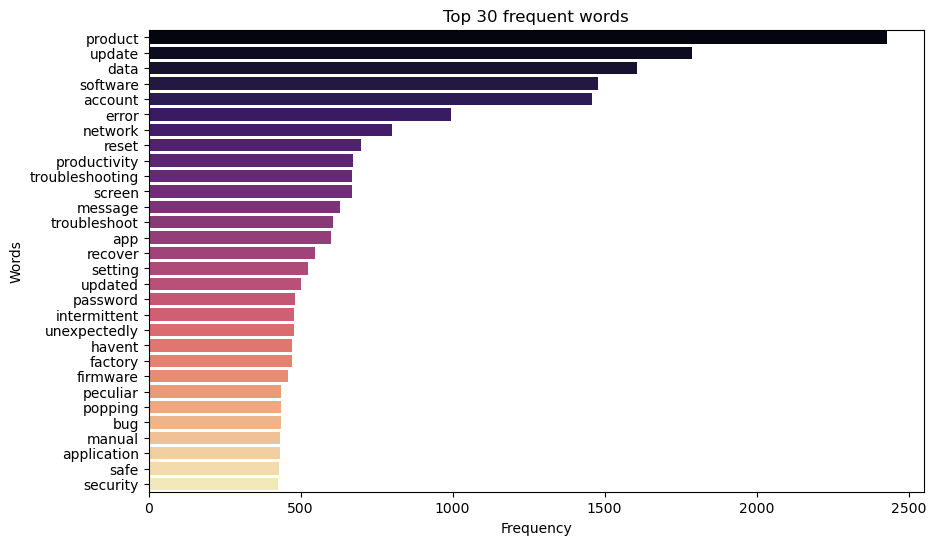

In [77]:
text_data = data_df['processed_text'].astype(str)
all_words = ' '.join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)
words, counts = zip(*common_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title('Top 30 frequent words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

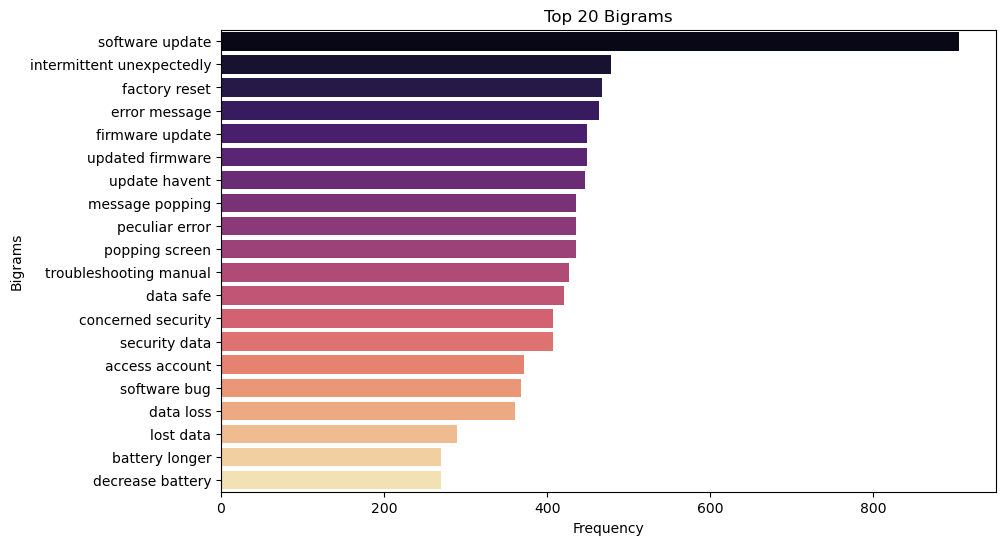

In [78]:
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title('Top 20 Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')
plt.show()

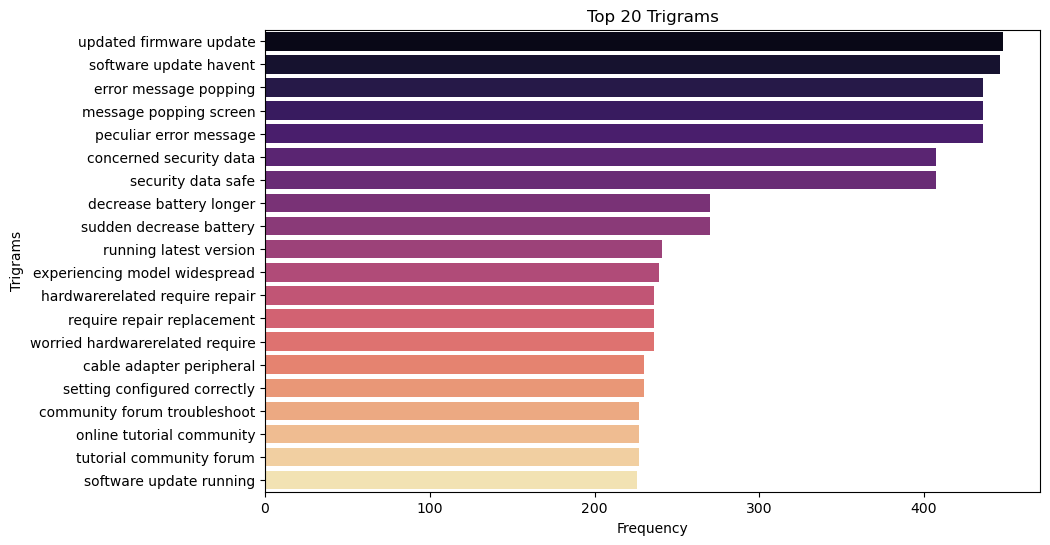

In [79]:
vectorizer = CountVectorizer(ngram_range=(3, 3), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title('Top 20 Trigrams')
plt.xlabel('Frequency')
plt.ylabel('Trigrams')
plt.show()

In [80]:
ut.save_data(data_df, 'cleaned_data.csv')

## 3. Text Representation

### 3.1 TF-IDF

In [81]:
def nlp_cleaner(text_list):
    results = []
    for text in text_list:
        cleaned = clean_text(text)
        processed = preprocess(cleaned)
        results.append(processed)
    return results

In [82]:
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=5, max_df=0.7)
X = tfidf.fit_transform(data_df['processed_text'])

In [83]:
tfidf__preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner, validate=False)),
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=5, max_df=0.7))
])

## 4. K-Means Clustering



### 4.0 K-Means on without dimensional-reduction


Baseline K-Means (no dim reduction) — TF-IDF:
  k= 2 | CV=0.811
  k= 3 | CV=1.057
  k= 4 | CV=1.313
  k= 5 | CV=1.386
  k= 6 | CV=1.331
  k= 7 | CV=1.158
  k= 8 | CV=1.143
  k= 9 | CV=1.214
  k=10 | CV=1.137
  k=11 | CV=2.049
  k=12 | CV=1.186
  k=13 | CV=1.911
  k=14 | CV=1.064
  k=15 | CV=1.227
  k=16 | CV=1.002
  k=17 | CV=0.960
  k=18 | CV=0.994
  k=19 | CV=1.361
  k=20 | CV=1.070

Best k — TF-IDF (raw): 2  CV=0.811


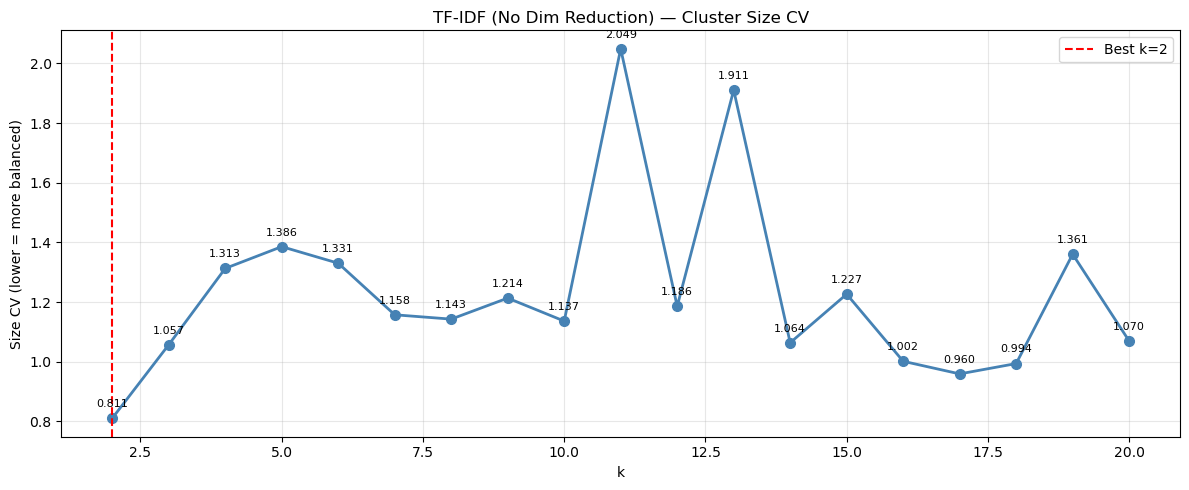

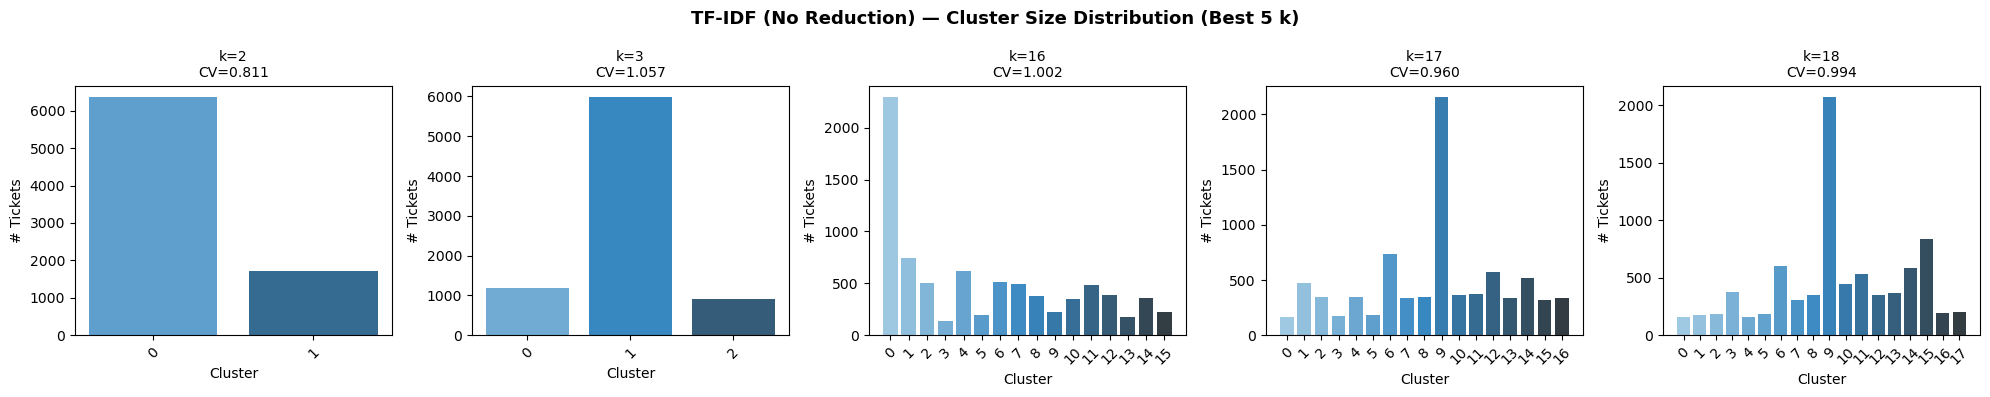


TF-IDF (No Reduction)  |  k=2  CV=0.811
  C00 (n=6354, dom=Software bug                  ): ['product', 'account', 'data', 'error', 'network', 'reset', 'troubleshooting', 'productivity']
  C01 (n=1723, dom=Hardware issue                ): ['update', 'software', 'havent', 'product', 'updated', 'firmware', 'data', 'version']

TF-IDF (No Reduction)  |  k=3  CV=1.057
  C00 (n=1197, dom=Battery life                  ): ['data', 'safe', 'security', 'concerned', 'file', 'loss', 'deleted', 'recover']
  C01 (n=5975, dom=Product compatibility         ): ['product', 'update', 'software', 'network', 'productivity', 'troubleshooting', 'troubleshoot', 'setting']
  C02 (n= 905, dom=Delivery problem              ): ['account', 'error', 'password', 'screen', 'message', 'peculiar', 'popping', 'access']

TF-IDF (No Reduction)  |  k=16  CV=1.002
  C00 (n=2292, dom=Product compatibility         ): ['product', 'productivity', 'longer', 'battery', 'decrease', 'sudden', 'setting', 'charging']
  C01 (n= 742, 

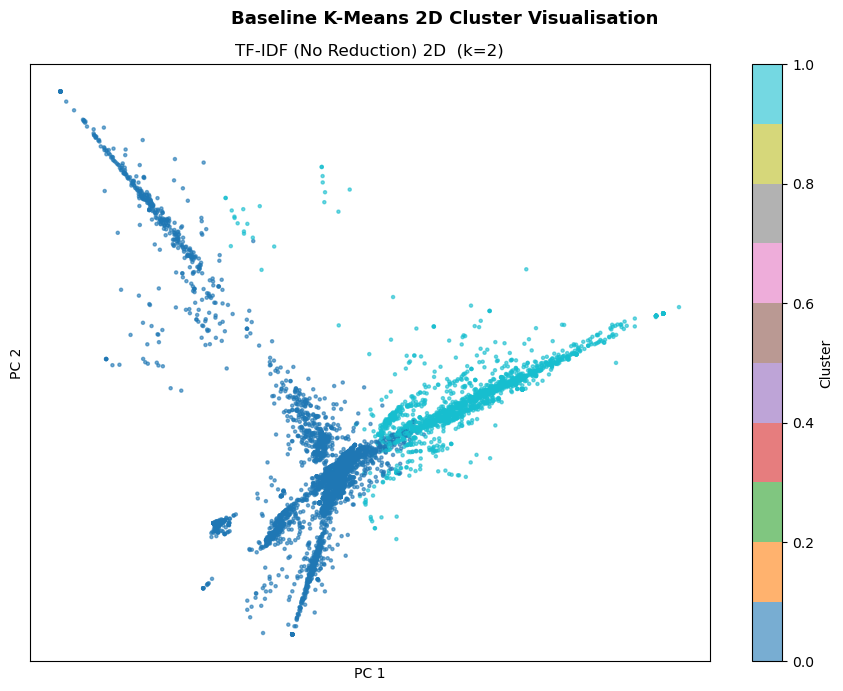

Saved: /Users/yukaining/Desktop/Introduction to AI and Text Analytics/TextAnalytics-CW-Task4/results_and_plots/kmeans_cv_no_reduction_results.txt


In [84]:
X_tfidf_raw = normalize(X).toarray()

K_RANGE_BASE = range(2, 21)
cv_base_tfidf = []

print('Baseline K-Means (no dim reduction) — TF-IDF:')
for k in K_RANGE_BASE:
    lbl_t = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_tfidf_raw)
    sz_t = pd.Series(lbl_t).value_counts()
    cv_base_tfidf.append(sz_t.std() / sz_t.mean())
    print(f'  k={k:2d} | CV={cv_base_tfidf[-1]:.3f}')

k_list_base = list(K_RANGE_BASE)
best_k_base_tfidf = k_list_base[np.argmin(cv_base_tfidf)]
print(f'\nBest k — TF-IDF (raw): {best_k_base_tfidf}  CV={min(cv_base_tfidf):.3f}')

# CV plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_list_base, cv_base_tfidf, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axvline(best_k_base_tfidf, color='red', linestyle='--', label=f'Best k={best_k_base_tfidf}')
ax.set_title('TF-IDF (No Dim Reduction) — Cluster Size CV', fontsize=12)
ax.set_xlabel('k'); ax.set_ylabel('Size CV (lower = more balanced)')
for k, c in zip(k_list_base, cv_base_tfidf):
    ax.annotate(f'{c:.3f}', (k, c), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Best 5 k (lowest CV)
sorted_k_base = sorted(k_list_base, key=lambda k: cv_base_tfidf[k_list_base.index(k)])
K_SHOW_BASE = sorted(sorted_k_base[:5])

def get_top_keywords(text_series, n=8):
    words = ' '.join(text_series).split()
    words = [w for w in words if len(w) > 3 and not w.isnumeric()]
    return [w for w, _ in Counter(words).most_common(n)]

# Cluster size distribution + keywords for each of best 5 k
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('TF-IDF (No Reduction) — Cluster Size Distribution (Best 5 k)', fontsize=13, fontweight='bold')
for col, k in enumerate(K_SHOW_BASE):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_tfidf_raw)
    sizes = pd.Series(labels).value_counts().sort_index()
    cv = sizes.std() / sizes.mean()
    axes[col].bar(sizes.index.astype(str), sizes.values, color=sns.color_palette('Blues_d', k))
    axes[col].set_title(f'k={k}\nCV={cv:.3f}', fontsize=10)
    axes[col].set_xlabel('Cluster'); axes[col].set_ylabel('# Tickets')
    axes[col].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

for k in K_SHOW_BASE:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_tfidf_raw)
    data_df['_tmp'] = labels
    cv = pd.Series(labels).value_counts().std() / pd.Series(labels).value_counts().mean()
    print(f'\n{"="*70}')
    print(f'TF-IDF (No Reduction)  |  k={k}  CV={cv:.3f}')
    print('='*70)
    for i in range(k):
        docs = data_df[data_df['_tmp'] == i]
        kw = get_top_keywords(docs['processed_text'])
        dom = docs['Ticket Subject'].value_counts().index[0] if len(docs) > 0 else 'N/A'
        print(f'  C{i:02d} (n={len(docs):4d}, dom={dom:<30s}): {kw}')

# 2D visualisation at best k
lbl_base_tfidf = KMeans(n_clusters=best_k_base_tfidf, random_state=42, n_init=10).fit_predict(X_tfidf_raw)
X_tfidf_raw_2d = PCA(n_components=2, random_state=42).fit_transform(X_tfidf_raw)
data_df['cluster_base_tfidf'] = lbl_base_tfidf

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(X_tfidf_raw_2d[:, 0], X_tfidf_raw_2d[:, 1], c=lbl_base_tfidf, cmap='tab10', s=5, alpha=0.6)
ax.set_title(f'TF-IDF (No Reduction) 2D  (k={best_k_base_tfidf})', fontsize=12)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(sc, ax=ax, label='Cluster')
plt.suptitle('Baseline K-Means 2D Cluster Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()




# ── Save baseline results 
import os
_out_dir = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'results_and_plots'))
os.makedirs(_out_dir, exist_ok=True)

_lines = []
_lines.append('=' * 70)
_lines.append('K-Means + TF-IDF (No Dim Reduction) | Metric: CV')
_lines.append(f'K range: {min(k_list_base)} - {max(k_list_base)}  |  Best k: {best_k_base_tfidf}  |  Best CV: {min(cv_base_tfidf):.4f}')
_lines.append(f'Best 5 k (lowest CV): {K_SHOW_BASE}')
_lines.append('=' * 70)
for k in K_SHOW_BASE:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_tfidf_raw)
    data_df['_tmp'] = labels
    sizes = pd.Series(labels).value_counts().sort_index()
    cv_k = sizes.std() / sizes.mean()
    _lines.append(f'\nk={k}  CV={cv_k:.4f}')
    _lines.append('-' * 50)
    for i in range(k):
        docs = data_df[data_df['_tmp'] == i]
        kw = get_top_keywords(docs['processed_text'])
        dom = docs['Ticket Subject'].value_counts().index[0] if len(docs) > 0 else 'N/A'
        _lines.append(f'  Cluster {i:02d} (n={len(docs):4d}) | {dom}')
        _lines.append(f'           Keywords: {", ".join(kw)}')
_out = os.path.join(_out_dir, 'kmeans_cv_no_reduction_results.txt')
with open(_out, 'w') as _f:
    _f.write('\n'.join(_lines))
print(f'Saved: {_out}')


### 4.1 Dimensionality Reduction (PCA)

In [85]:
X_tfidf_norm = normalize(X)

# PCA-100 for TF-IDF clustering
pca100 = PCA(n_components=100, random_state=42)
X_tfidf_pca = pca100.fit_transform(X_tfidf_norm.toarray())
print(f'PCA-100 variance explained: {pca100.explained_variance_ratio_.sum()*100:.1f}%')

# PCA-2D for TF-IDF visualisation
pca2d = PCA(n_components=2, random_state=42)
X_tfidf_2d = pca2d.fit_transform(X_tfidf_norm.toarray())
print(f'TF-IDF PCA-2D shape: {X_tfidf_2d.shape}')


PCA-100 variance explained: 65.0%
TF-IDF PCA-2D shape: (8077, 2)


### 4.2 K Sweep (k = 5 to 10)
#### CV small and inertia small is better

In [86]:
K_RANGE = range(2, 21)
inertia_tfidf = []
cv_tfidf = []

for k in K_RANGE:
    km_t = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_t = km_t.fit_predict(X_tfidf_pca)
    inertia_tfidf.append(km_t.inertia_)
    sz_t = pd.Series(lbl_t).value_counts()
    cv_tfidf.append(sz_t.std() / sz_t.mean())
    print(f'k={k:2d} | inertia={inertia_tfidf[-1]:8.1f}, CV={cv_tfidf[-1]:.3f}')

k_list = list(K_RANGE)
best_k_tfidf = k_list[np.argmin(cv_tfidf)]
print(f'\nBest k — TF-IDF + PCA: {best_k_tfidf}  CV={min(cv_tfidf):.3f}')


k= 2 | inertia=  4887.3, CV=1.226
k= 3 | inertia=  4719.7, CV=1.110
k= 4 | inertia=  4633.5, CV=1.662
k= 5 | inertia=  4517.1, CV=1.795
k= 6 | inertia=  4362.2, CV=1.759
k= 7 | inertia=  4231.2, CV=1.491
k= 8 | inertia=  4139.6, CV=1.560
k= 9 | inertia=  4038.1, CV=1.637
k=10 | inertia=  3896.4, CV=2.059
k=11 | inertia=  3760.7, CV=2.002
k=12 | inertia=  3685.2, CV=1.716
k=13 | inertia=  3548.8, CV=1.885
k=14 | inertia=  3479.2, CV=1.890
k=15 | inertia=  3354.8, CV=1.805
k=16 | inertia=  3254.2, CV=1.814
k=17 | inertia=  3172.3, CV=1.824
k=18 | inertia=  3061.7, CV=1.602
k=19 | inertia=  3003.4, CV=1.771
k=20 | inertia=  2923.3, CV=1.234

Best k — TF-IDF + PCA: 3  CV=1.110


### 4.3 Elbow & Cluster Size CV


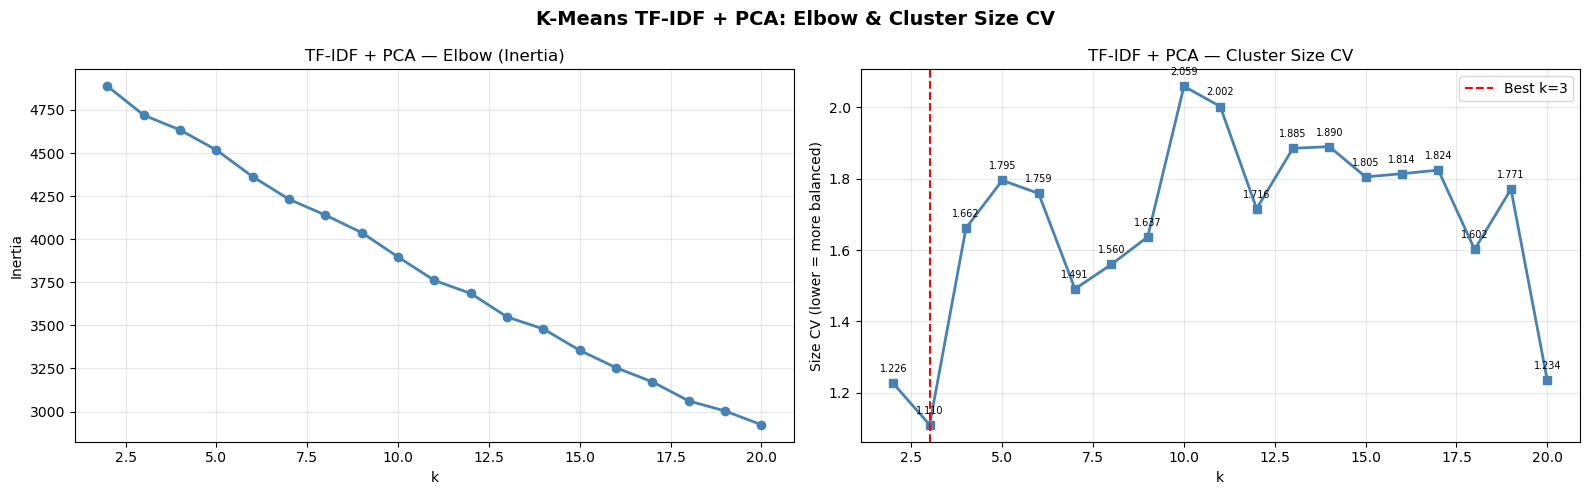

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('K-Means TF-IDF + PCA: Elbow & Cluster Size CV', fontsize=14, fontweight='bold')

axes[0].plot(k_list, inertia_tfidf, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('TF-IDF + PCA — Elbow (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_list, cv_tfidf, 's-', color='steelblue', linewidth=2)
axes[1].axvline(best_k_tfidf, color='red', linestyle='--', label=f'Best k={best_k_tfidf}')
axes[1].set_title('TF-IDF + PCA — Cluster Size CV')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Size CV (lower = more balanced)')
for k, c in zip(k_list, cv_tfidf):
    axes[1].annotate(f'{c:.3f}', (k, c), textcoords='offset points', xytext=(0,8), ha='center', fontsize=7)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


### 4.4 2D Cluster Visualisation

In [88]:
# Assign best-k labels
lbl_tfidf_best = KMeans(n_clusters=best_k_tfidf, random_state=42, n_init=10).fit_predict(X_tfidf_pca)


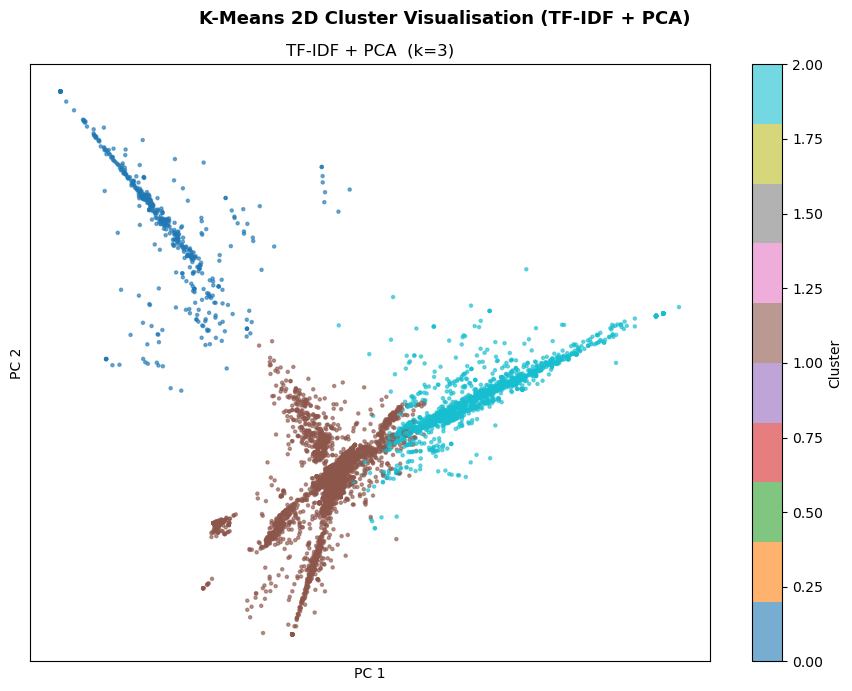

In [89]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(X_tfidf_2d[:, 0], X_tfidf_2d[:, 1], c=lbl_tfidf_best, cmap='tab10', s=5, alpha=0.6)
ax.set_title(f'TF-IDF + PCA  (k={best_k_tfidf})', fontsize=12)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(sc, ax=ax, label='Cluster')
plt.suptitle('K-Means 2D Cluster Visualisation (TF-IDF + PCA)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### 4.6 Cluster Size Distribution

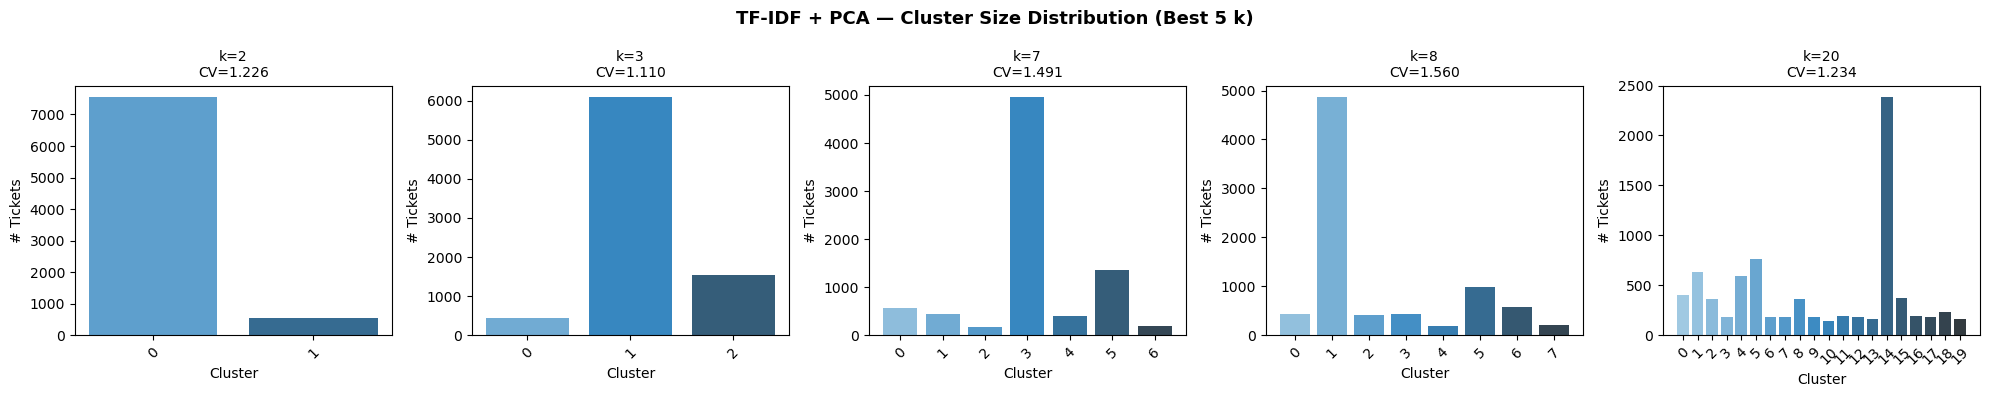


TF-IDF + PCA  |  k=2  CV=1.226
  C00 (n=7540, dom=Software bug                  ): ['product', 'update', 'data', 'software', 'network', 'error', 'screen', 'productivity']
  C01 (n= 537, dom=Delivery problem              ): ['account', 'password', 'access', 'reset', 'login', 'recover', 'error', 'forgotten']

TF-IDF + PCA  |  k=3  CV=1.110
  C00 (n= 441, dom=Battery life                  ): ['error', 'screen', 'message', 'peculiar', 'popping', 'product', 'account', 'data']
  C01 (n=6084, dom=Software bug                  ): ['product', 'data', 'account', 'troubleshooting', 'reset', 'productivity', 'network', 'troubleshoot']
  C02 (n=1552, dom=Hardware issue                ): ['update', 'software', 'havent', 'updated', 'product', 'firmware', 'version', 'running']

TF-IDF + PCA  |  k=7  CV=1.491
  C00 (n= 565, dom=Battery life                  ): ['error', 'message', 'screen', 'peculiar', 'popping', 'data', 'file', 'loss']
  C01 (n= 440, dom=Account access                ): ['intermittent

In [90]:
# Best 5 k (lowest CV)
sorted_k = sorted(k_list, key=lambda k: cv_tfidf[k_list.index(k)])
K_SHOW = sorted(sorted_k[:5])

def get_top_keywords(text_series, n=8):
    words = ' '.join(text_series).split()
    words = [w for w in words if len(w) > 3 and not w.isnumeric()]
    return [w for w, _ in Counter(words).most_common(n)]

# Cluster size distribution
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('TF-IDF + PCA — Cluster Size Distribution (Best 5 k)', fontsize=13, fontweight='bold')
for col, k in enumerate(K_SHOW):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_tfidf_pca)
    sizes = pd.Series(labels).value_counts().sort_index()
    cv = sizes.std() / sizes.mean()
    axes[col].bar(sizes.index.astype(str), sizes.values, color=sns.color_palette('Blues_d', k))
    axes[col].set_title(f'k={k}\nCV={cv:.3f}', fontsize=10)
    axes[col].set_xlabel('Cluster'); axes[col].set_ylabel('# Tickets')
    axes[col].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

# Keywords for each of best 5 k
for k in K_SHOW:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_tfidf_pca)
    data_df['_tmp'] = labels
    cv = pd.Series(labels).value_counts().std() / pd.Series(labels).value_counts().mean()
    print(f'\n{"="*70}')
    print(f'TF-IDF + PCA  |  k={k}  CV={cv:.3f}')
    print('='*70)
    for i in range(k):
        docs = data_df[data_df['_tmp'] == i]
        kw = get_top_keywords(docs['processed_text'])
        dom = docs['Ticket Subject'].value_counts().index[0] if len(docs) > 0 else 'N/A'
        print(f'  C{i:02d} (n={len(docs):4d}, dom={dom:<30s}): {kw}')





# ── Save TF-IDF + PCA results 
import os
_out_dir = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'results_and_plots'))
os.makedirs(_out_dir, exist_ok=True)

_lines = []
_lines.append('=' * 70)
_lines.append('K-Means + TF-IDF + PCA | Metric: CV')
_lines.append(f'K range: {min(k_list)} - {max(k_list)}  |  Best k: {best_k_tfidf}  |  Best CV: {min(cv_tfidf):.4f}')
_lines.append(f'Best 5 k (lowest CV): {K_SHOW}')
_lines.append('=' * 70)
for k in K_SHOW:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_tfidf_pca)
    data_df['_tmp'] = labels
    sizes = pd.Series(labels).value_counts().sort_index()
    cv_k = sizes.std() / sizes.mean()
    _lines.append(f'\nk={k}  CV={cv_k:.4f}')
    _lines.append('-' * 50)
    for i in range(k):
        docs = data_df[data_df['_tmp'] == i]
        kw = get_top_keywords(docs['processed_text'])
        dom = docs['Ticket Subject'].value_counts().index[0] if len(docs) > 0 else 'N/A'
        _lines.append(f'  Cluster {i:02d} (n={len(docs):4d}) | {dom}')
        _lines.append(f'           Keywords: {", ".join(kw)}')
_out = os.path.join(_out_dir, 'kmeans_cv_pca_results.txt')
with open(_out, 'w') as _f:
    _f.write('\n'.join(_lines))
print(f'Saved: {_out}')
